In [1]:
# ライブラリのインストール
!pip install kaggle --quiet

# kaggle.jsonのアップロード
from google.colab import files
uploaded = files.upload()  # ここでkaggle.jsonを選択してアップロード

# kaggle.jsonを正しい場所に配置し、権限を設定
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Titanicコンペティションのデータをダウンロードして展開
!kaggle competitions download -c titanic
!unzip -o titanic.zip -d titanic_data

# データの読み込みと確認
import pandas as pd

train_df = pd.read_csv('titanic_data/train.csv')
test_df = pd.read_csv('titanic_data/test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Saving kaggle.json to kaggle.json
100% 34.1k/34.1k [00:00<00:00, 51.4MB/s]

Archive:  titanic.zip
  inflating: titanic_data/gender_submission.csv  
  inflating: titanic_data/test.csv   
  inflating: titanic_data/train.csv  
Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


=== Missing Values (train) ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== Missing Values (test) ===
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

=== Train Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp    

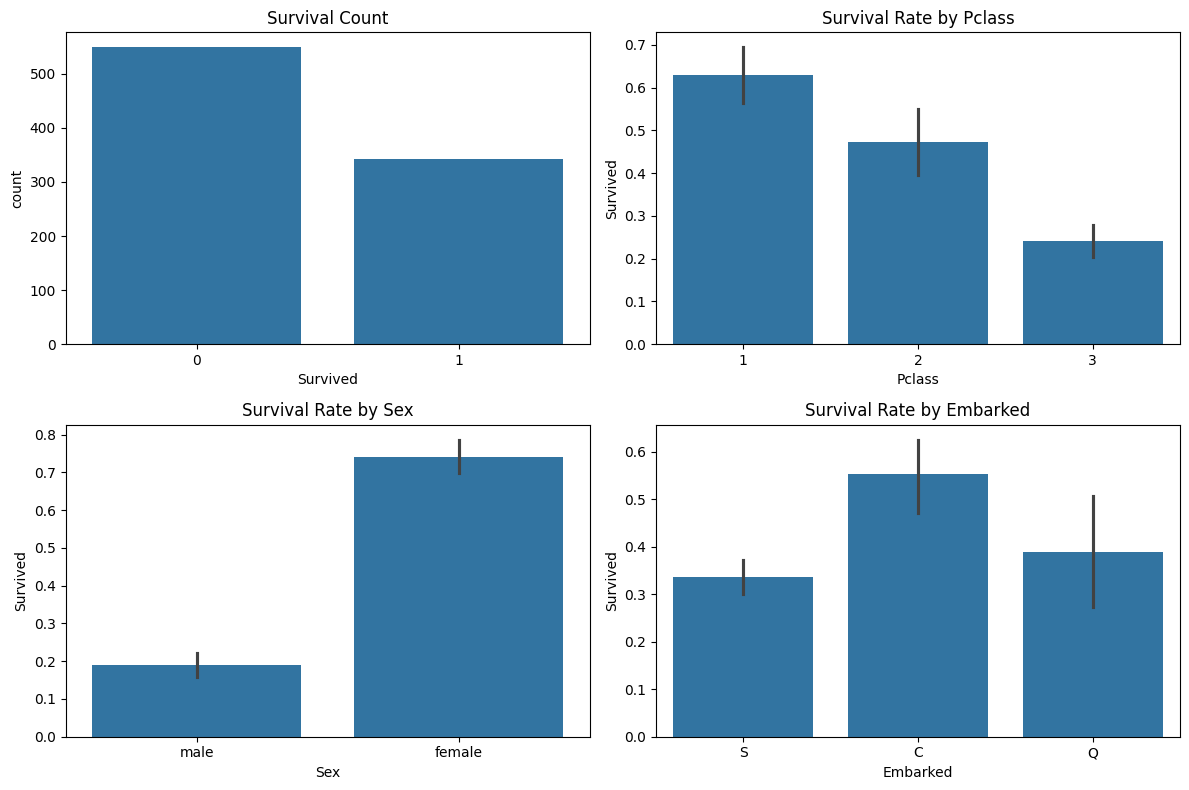

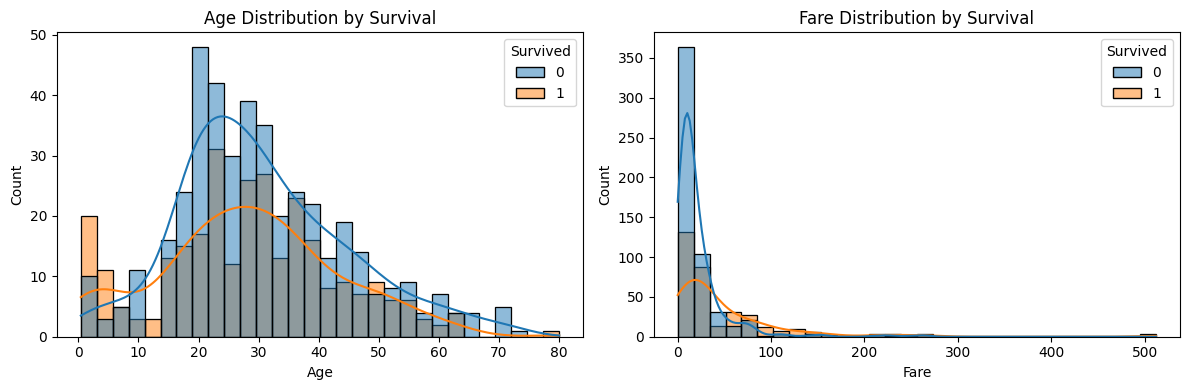

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 欠損値の確認
print("=== Missing Values (train) ===")
print(train_df.isnull().sum())
print("\n=== Missing Values (test) ===")
print(test_df.isnull().sum())

# 基本統計量
print("\n=== Train Info ===")
train_df.info()
print("\n=== Train Describe ===")
print(train_df.describe())

# 目的変数(Survived)の分布
print("\n=== Survived Distribution ===")
print(train_df['Survived'].value_counts(normalize=True))

# 可視化: 生存率とカテゴリ変数の関係
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=train_df, x='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Count')

sns.barplot(data=train_df, x='Pclass', y='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Pclass')

sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1, 0])
axes[1, 0].set_title('Survival Rate by Sex')

sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Survival Rate by Embarked')

plt.tight_layout()
plt.show()

# 数値変数(Age, Fare)と生存の関係
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0], bins=30)
axes[0].set_title('Age Distribution by Survival')

sns.histplot(data=train_df, x='Fare', hue='Survived', kde=True, ax=axes[1], bins=30)
axes[1].set_title('Fare Distribution by Survival')

plt.tight_layout()
plt.show()

=== Age stats by Title ===
              count  median       mean        std
Title                                            
Master           36     3.5   4.574167   3.619872
Miss            149    21.0  21.845638  12.870542
Mr              398    30.0  32.368090  12.708793
Mrs             109    35.0  35.788991  11.437490
Rare             21    49.0  46.142857  11.727258
the Countess      1    33.0  33.000000        NaN

Overall Age median: 28.0

=== Age stats by Pclass & Sex ===
               count  median       mean        std
Pclass Sex                                        
1      female     85    35.0  34.611765  13.612052
       male      101    40.0  41.281386  15.139570
2      female     74    28.0  28.722973  12.872702
       male       99    30.0  30.740707  14.793894
3      female    102    21.5  21.750000  12.729964
       male      253    25.0  26.507589  12.159514


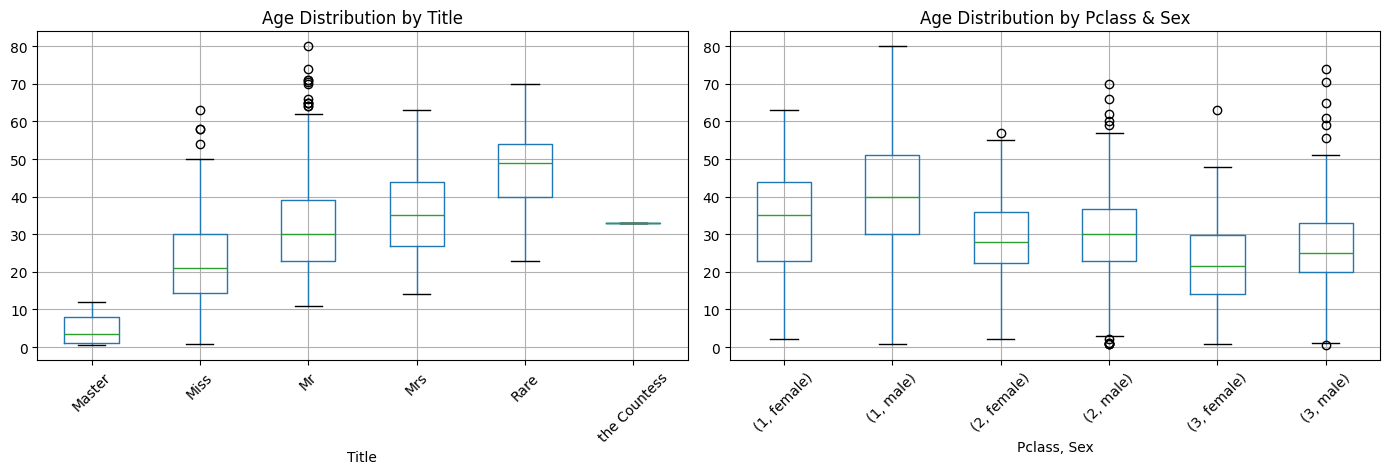

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Titleの抽出(この処理自体はリークを生まない。Nameの文字列パターンのみに依存するため)
train_df['Title'] = train_df['Name'].str.extract(r',\s*([^\.]+)\.')
title_mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare'
}
train_df['Title'] = train_df['Title'].replace(title_mapping)

# Title別のAge統計量
print("=== Age stats by Title ===")
print(train_df.groupby('Title')['Age'].agg(['count', 'median', 'mean', 'std']))

# 全体のAge中央値との比較用の基準値
overall_median = train_df['Age'].median()
print(f"\nOverall Age median: {overall_median}")

# Pclass・Sex別の中央値も併せて確認(Titleを使わない場合の代替案として)
print("\n=== Age stats by Pclass & Sex ===")
print(train_df.groupby(['Pclass', 'Sex'])['Age'].agg(['count', 'median', 'mean', 'std']))

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df.boxplot(column='Age', by='Title', ax=axes[0])
axes[0].set_title('Age Distribution by Title')
axes[0].set_xlabel('Title')
axes[0].tick_params(axis='x', rotation=45)

train_df.boxplot(column='Age', by=['Pclass', 'Sex'], ax=axes[1])
axes[1].set_title('Age Distribution by Pclass & Sex')
axes[1].set_xlabel('Pclass, Sex')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

train_df['Deck'] = train_df['Cabin'].str[0]

print("=== Survival Rate by Deck (missing excluded) ===")
print(train_df.groupby('Deck')['Survived'].agg(['count', 'mean']))

print(f"\nOverall survival rate: {train_df['Survived'].mean():.4f}")

=== Survival Rate by Deck (missing excluded) ===
      count      mean
Deck                 
A        15  0.466667
B        47  0.744681
C        59  0.593220
D        33  0.757576
E        32  0.750000
F        13  0.615385
G         4  0.500000
T         1  0.000000

Overall survival rate: 0.3838


In [5]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

TITLE_MAPPING = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'the Countess': 'Rare',
    'Capt': 'Rare', 'Col': 'Rare', 'Don': 'Rare', 'Dr': 'Rare',
    'Major': 'Rare', 'Rev': 'Rare', 'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}

class TitleExtractor(BaseEstimator, TransformerMixin):
    """Nameから敬称(Title)を抽出する。行単位の文字列処理のみのためリークは発生しない。"""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['Title'] = X['Name'].str.extract(r',\s*([^\.]+)\.')[0]
        X['Title'] = X['Title'].replace(TITLE_MAPPING)
        return X

class FamilyFeatures(BaseEstimator, TransformerMixin):
    """FamilySize, IsAlone, HasCabinを作成する。行単位の計算のみのためリークは発生しない。"""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
        X['HasCabin'] = X['Cabin'].notna().astype(int)
        return X

class AgeImputer(BaseEstimator, TransformerMixin):
    """Title別のAge中央値で欠損を補完する。中央値はfit時(=学習foldのみ)に算出し、検証foldには適用のみ行うためリークしない。"""
    def fit(self, X, y=None):
        self.title_medians_ = X.groupby('Title')['Age'].median()
        self.overall_median_ = X['Age'].median()
        return self
    def transform(self, X):
        X = X.copy()
        def fill(row):
            if pd.isna(row['Age']):
                med = self.title_medians_.get(row['Title'], np.nan)
                return med if not pd.isna(med) else self.overall_median_
            return row['Age']
        X['Age'] = X.apply(fill, axis=1)
        return X

class FareImputer(BaseEstimator, TransformerMixin):
    """Pclass別のFare中央値で欠損を補完する。中央値はfit時(=学習foldのみ)に算出する。"""
    def fit(self, X, y=None):
        self.pclass_medians_ = X.groupby('Pclass')['Fare'].median()
        self.overall_median_ = X['Fare'].median()
        return self
    def transform(self, X):
        X = X.copy()
        def fill(row):
            if pd.isna(row['Fare']):
                med = self.pclass_medians_.get(row['Pclass'], np.nan)
                return med if not pd.isna(med) else self.overall_median_
            return row['Fare']
        X['Fare'] = X.apply(fill, axis=1)
        return X

class EmbarkedImputer(BaseEstimator, TransformerMixin):
    """Embarkedの欠損を学習foldの最頻値で補完する。"""
    def fit(self, X, y=None):
        self.mode_ = X['Embarked'].mode()[0]
        return self
    def transform(self, X):
        X = X.copy()
        X['Embarked'] = X['Embarked'].fillna(self.mode_)
        return X

class ColumnSelector(BaseEstimator, TransformerMixin):
    """最終的にモデルへ渡す列だけを残す。"""
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns]

feature_columns = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']
numeric_features = ['Age', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

full_pipeline = Pipeline(steps=[
    ('title_extractor', TitleExtractor()),
    ('family_features', FamilyFeatures()),
    ('age_imputer', AgeImputer()),
    ('fare_imputer', FareImputer()),
    ('embarked_imputer', EmbarkedImputer()),
    ('column_selector', ColumnSelector(feature_columns)),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

X = train_df.drop(columns=['Survived'])
y = train_df['Survived']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(full_pipeline, X, y, cv=skf, scoring='roc_auc')

print("ROC-AUC scores per fold:", scores)
print(f"Mean ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

ROC-AUC scores per fold: [0.89888011 0.86858289 0.85006684 0.85882353 0.89376413]
Mean ROC-AUC: 0.8740 (+/- 0.0192)


In [6]:
# 必要ライブラリのインストール
!pip install optuna lightgbm --quiet

import time
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNING_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
OPTUNA_TIMEOUT_SECONDS = 120


def build_pipeline(classifier):
    """前処理パイプライン(title_extractor〜preprocessor)に、指定した分類器を接続する。"""
    return Pipeline(steps=[
        ('title_extractor', TitleExtractor()),
        ('family_features', FamilyFeatures()),
        ('age_imputer', AgeImputer()),
        ('fare_imputer', FareImputer()),
        ('embarked_imputer', EmbarkedImputer()),
        ('column_selector', ColumnSelector(feature_columns)),
        ('preprocessor', preprocessor),
        ('classifier', classifier),
    ])


def evaluate_pipeline(classifier):
    """指定した分類器をパイプラインに組み込み、CVでのROC-AUC平均を返す。"""
    pipeline = build_pipeline(classifier)
    scores = cross_val_score(pipeline, X, y, cv=TUNING_CV, scoring='roc_auc', n_jobs=1)
    return scores.mean()


def logistic_regression_objective(trial):
    classifier = LogisticRegression(
        C=trial.suggest_float('C', 1e-3, 1e2, log=True),
        penalty='l2',
        max_iter=1000,
    )
    return evaluate_pipeline(classifier)


def knn_objective(trial):
    classifier = KNeighborsClassifier(
        n_neighbors=trial.suggest_int('n_neighbors', 3, 30),
        weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
        p=trial.suggest_int('p', 1, 2),  # 1=マンハッタン距離, 2=ユークリッド距離
    )
    return evaluate_pipeline(classifier)


def svm_objective(trial):
    """SVMは計算コストが高いため、探索中はprobability=Falseにしdecision_functionで評価する。
    cache_sizeとn_jobsで高速化し、遅くなりやすいpolyカーネルは探索対象から除外する。"""
    classifier = SVC(
        C=trial.suggest_float('C', 1e-2, 1e2, log=True),
        kernel=trial.suggest_categorical('kernel', ['rbf', 'linear']),
        gamma=trial.suggest_float('gamma', 1e-4, 1e0, log=True),
        probability=False,
        cache_size=1000,
    )
    pipeline = build_pipeline(classifier)
    scores = cross_val_score(pipeline, X, y, cv=TUNING_CV, scoring='roc_auc', n_jobs=-1)
    return scores.mean()


def decision_tree_objective(trial):
    classifier = DecisionTreeClassifier(
        max_depth=trial.suggest_int('max_depth', 2, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
        random_state=42,
    )
    return evaluate_pipeline(classifier)


def random_forest_objective(trial):
    classifier = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 2, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
        n_jobs=-1,
        random_state=42,
    )
    return evaluate_pipeline(classifier)


def lightgbm_objective(trial):
    classifier = LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 3e-1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 63),
        max_depth=trial.suggest_int('max_depth', 2, 12),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    return evaluate_pipeline(classifier)


# モデル名と対応するobjective関数の対応表
model_objectives = {
    'LogisticRegression': logistic_regression_objective,
    'KNN': knn_objective,
    'SVM': svm_objective,
    'DecisionTree': decision_tree_objective,
    'RandomForest': random_forest_objective,
    'LightGBM': lightgbm_objective,
}

tuning_results = {}

for model_name, objective_function in model_objectives.items():
    print(f'--- Tuning {model_name} (max {OPTUNA_TIMEOUT_SECONDS} seconds) ---')

    start_time = time.time()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective_function, timeout=OPTUNA_TIMEOUT_SECONDS)
    elapsed_time = time.time() - start_time

    tuning_results[model_name] = {
        'best_score': study.best_value,
        'best_params': study.best_params,
        'n_trials': len(study.trials),
        'elapsed_seconds': elapsed_time,
    }

    print(f'Best ROC-AUC: {study.best_value:.4f} | Trials: {len(study.trials)} | Elapsed: {elapsed_time:.1f}s')
    print(f'Best params: {study.best_params}\n')

# 全モデルの結果をまとめて表示
import pandas as pd

results_df = pd.DataFrame(tuning_results).T.sort_values('best_score', ascending=False)
print(results_df)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.5 MB/s eta 0:00:00
--- Tuning LogisticRegression (max 120 seconds) ---
Best ROC-AUC: 0.8743 | Trials: 393 | Elapsed: 120.1s
Best params: {'C': 6.172279421598737}

--- Tuning KNN (max 120 seconds) ---
Best ROC-AUC: 0.8741 | Trials: 725 | Elapsed: 120.1s
Best params: {'n_neighbors': 7, 'weights': 'uniform', 'p': 1}

--- Tuning SVM (max 120 seconds) ---
Best ROC-AUC: 0.8637 | Trials: 469 | Elapsed: 120.1s
Best params: {'C': 5.420895149429985, 'kernel': 'rbf', 'gamma': 0.000506264332113341}

--- Tuning DecisionTree (max 120 seconds) ---
Best ROC-AUC: 0.8626 | Trials: 804 | Elapsed: 120.0s
Best params: {'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 20}

--- Tuning RandomForest (max 120 seconds) ---
Best ROC-AUC: 0.8863 | Trials: 45 | Elapsed: 121.2s
Best params: {'n_estimators': 352, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Best ROC-AUC: 0.8902 | Trials: 147 | Elapsed: 120.6s
Best params: {'n_estimators': 350, 'learning_rate': 0.004775396345124887, 'num_leaves': 50, 'max_depth': 12, 'min_child_samples': 8, 'subsample': 0.9627359049804645, 'colsample_bytree': 0.5541292341918392}

                   best_score  \
LightGBM             0.890183   
RandomForest         0.886284   
LogisticRegression   0.874349   
KNN                  0.874093   
SVM                  0.863676   
DecisionTree         0.862637   

                                                          best_params  \
LightGBM            {'n_estimators': 350, 'learning_rate': 0.00477...   
RandomForest        {'n_estimators': 352, 'max_depth': 20, 'min_sa...   
LogisticRegression                           {'C': 6.172279421598737}   
KNN                  {'n_neighbors': 7, 'weights': 'uniform', 'p': 1}   
SVM                 {'C': 5.420895149429985, 'kernel': 'rbf', 'gam...   
DecisionTree        {'max_depth': 5, 'min_samples_split': 4, 'min_... 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


=== Feature Importance (Mean Absolute SHAP Value) ===
          feature  mean_abs_shap_value
    cat__Title_Mr             0.609175
  cat__Sex_female             0.260648
    cat__Pclass_3             0.186962
        num__Fare             0.186629
         num__Age             0.152392
    num__HasCabin             0.131410
    cat__Sex_male             0.124618
  num__FamilySize             0.116689
    cat__Pclass_1             0.069052
  cat__Embarked_S             0.052791
cat__Title_Master             0.040329
  cat__Embarked_C             0.035423
    cat__Pclass_2             0.033610
  cat__Title_Rare             0.022924
   cat__Title_Mrs             0.019973
  cat__Title_Miss             0.009910
     num__IsAlone             0.008523
  cat__Embarked_Q             0.007549

=== Feature Importance (LightGBM Gain-based) ===
          feature  gain_importance
    cat__Title_Mr     17641.856423
        num__Fare     10760.514561
         num__Age      8118.475091
  cat__Sex_fema

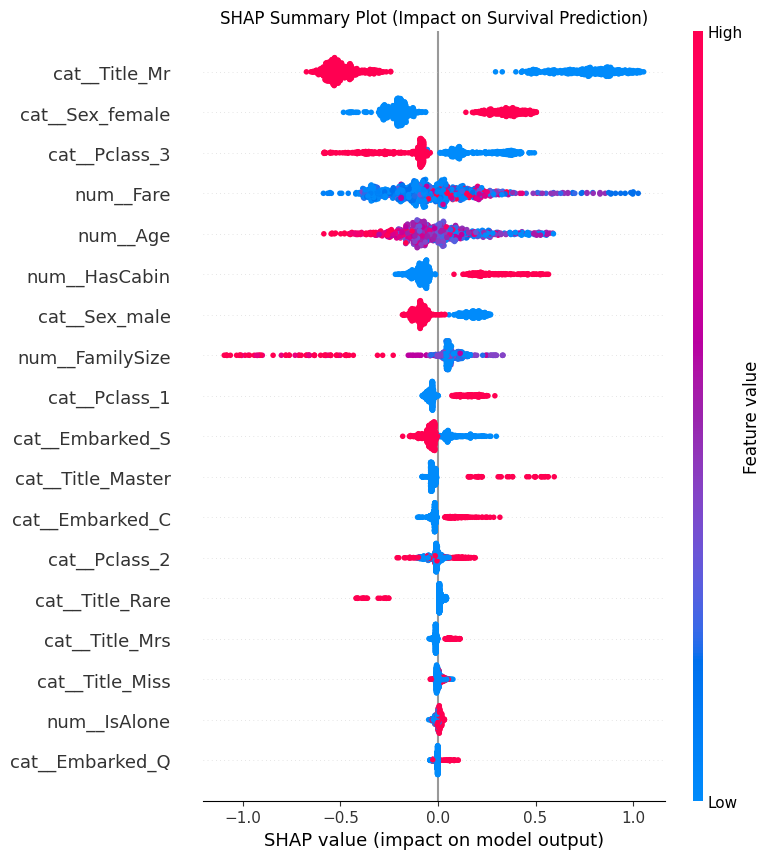

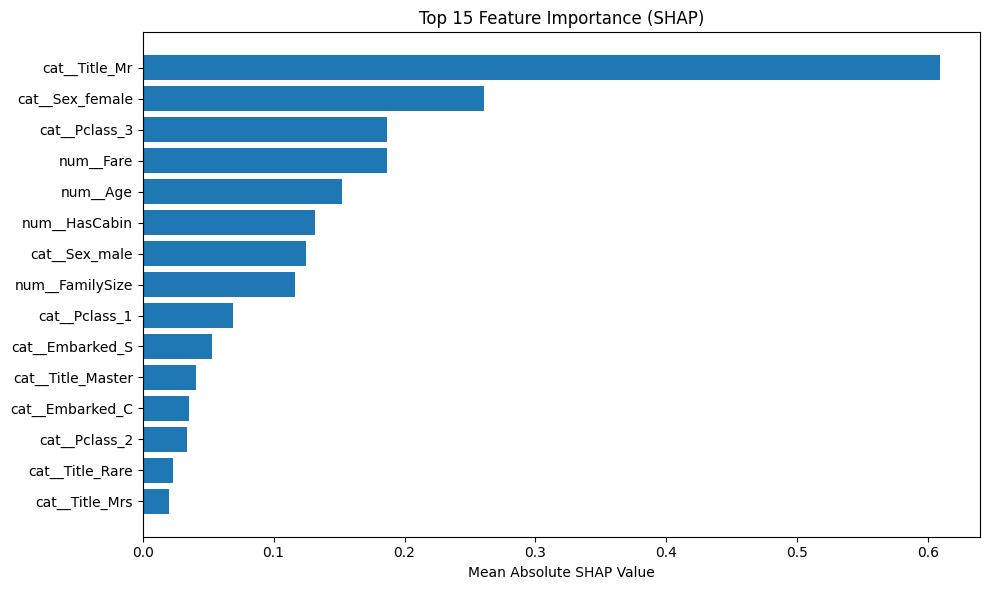

In [7]:
# 必要ライブラリのインストール
!pip install shap --quiet

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

# 前処理済みパイプラインと、最良パラメータのLightGBMを結合して最終モデルを構築
best_lgbm_params = tuning_results['LightGBM']['best_params']
final_classifier = LGBMClassifier(**best_lgbm_params, random_state=42, n_jobs=-1, verbose=-1)
final_pipeline = build_pipeline(final_classifier)
final_pipeline.fit(X, y)

# SHAPはモデルへの入力(前処理後の数値配列)が必要なため、前処理部分だけを取り出して変換する
preprocessing_pipeline = Pipeline(steps=final_pipeline.steps[:-1])  # classifier以外の全ステップ
X_transformed = preprocessing_pipeline.transform(X)

# 前処理後の列名を取得(One-Hotエンコーディングで列が増えているため)
feature_names_out = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names_out)

# 学習済みLightGBM本体を取り出してSHAP値を計算
trained_lgbm = final_pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(trained_lgbm)
shap_values = explainer.shap_values(X_transformed_df)

# 二値分類の場合、shap_valuesがクラスごとにリストで返ることがあるため統一的に扱う
if isinstance(shap_values, list):
    shap_values_for_positive_class = shap_values[1]
else:
    shap_values_for_positive_class = shap_values

# 特徴量重要度の数値算出(平均絶対SHAP値)
mean_abs_shap = np.abs(shap_values_for_positive_class).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': feature_names_out,
    'mean_abs_shap_value': mean_abs_shap,
}).sort_values('mean_abs_shap_value', ascending=False).reset_index(drop=True)

print("=== Feature Importance (Mean Absolute SHAP Value) ===")
print(shap_importance_df.to_string(index=False))

# LightGBM組み込みの特徴量重要度(gain基準)も併せて算出し、SHAPとの違いを比較する
builtin_importance_df = pd.DataFrame({
    'feature': feature_names_out,
    'gain_importance': trained_lgbm.booster_.feature_importance(importance_type='gain'),
}).sort_values('gain_importance', ascending=False).reset_index(drop=True)

print("\n=== Feature Importance (LightGBM Gain-based) ===")
print(builtin_importance_df.to_string(index=False))

# 可視化1: SHAP summary plot(各特徴量が予測にどう影響するかの分布)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_for_positive_class, X_transformed_df, show=False)
plt.title('SHAP Summary Plot (Impact on Survival Prediction)')
plt.tight_layout()
plt.show()

# 可視化2: 平均絶対SHAP値の棒グラフ(重要度の大小を数値として見やすくする)
plt.figure(figsize=(10, 6))
plt.barh(shap_importance_df['feature'][:15][::-1], shap_importance_df['mean_abs_shap_value'][:15][::-1])
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Top 15 Feature Importance (SHAP)')
plt.tight_layout()
plt.show()